In [1]:
import pandas as pd
import numpy as np

In [2]:
df=pd.read_csv("features_from_mat.csv")
df.head()

,max,min,mean,sd,rms,skewness,kurtosis,crest,form,fault
0,0.783121,-0.999998,-2.677552e-09,0.280982,0.280982,-0.118659,-0.039330,3.558925,1.259595,Ball
1,0.999998,-0.860608,-3.841706e-09,0.297344,0.297344,0.174825,-0.078699,3.363085,1.242650,Ball
2,0.977138,-0.999998,2.153683e-09,0.326267,0.326267,0.040369,-0.271400,3.064963,1.253744,Ball
3,0.999650,-0.999998,-1.047738e-09,0.278427,0.278427,-0.023283,0.137756,3.591586,1.256890,Ball
4,0.706544,-0.999998,-4.016329e-09,0.229846,0.229846,-0.081593,0.406101,4.350707,1.276972,Ball


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2369 entries, 0 to 2368
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   max       2369 non-null   float64
 1   min       2369 non-null   float64
 2   mean      2369 non-null   float64
 3   sd        2369 non-null   float64
 4   rms       2369 non-null   float64
 5   skewness  2369 non-null   float64
 6   kurtosis  2369 non-null   float64
 7   crest     2369 non-null   float64
 8   form      2369 non-null   float64
 9   fault     2369 non-null   object 
dtypes: float64(9), object(1)
memory usage: 185.2+ KB


In [5]:
df.describe()

,max,min,mean,sd,rms,skewness,kurtosis,crest,form
count,2369.000000,2369.000000,2.369000e+03,2369.000000,2369.000000,2369.000000,2369.000000,2369.000000,2369.000000
mean,0.956682,-0.962124,-7.521663e-12,0.253136,0.253136,-0.038132,2.614850,4.225392,1.392795
std,0.066454,0.059172,1.965488e-09,0.059809,0.059809,0.180012,4.479394,1.216318,0.210457
min,0.589624,-1.000000,-1.047738e-08,0.113615,0.113615,-1.090735,-0.801650,2.523450,1.193114
25%,0.934523,-0.999998,-1.047738e-09,0.206657,0.206657,-0.089656,-0.041045,3.320812,1.254358
50%,0.994273,-0.999995,5.820766e-11,0.260268,0.260268,0.008272,0.587840,3.842178,1.295078
75%,0.999998,-0.937443,1.047738e-09,0.301129,0.301129,0.059112,3.912110,4.838908,1.475232
max,1.000000,-0.592818,6.635673e-09,0.396281,0.396281,1.060232,30.418056,8.801571,2.433896


In [7]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, f1_score
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import resample
from xgboost import XGBClassifier
import joblib

# 1. 데이터 불러오기
df = pd.read_csv("C:/Users/enjoy/Downloads/archive (2)/raw/static/features_from_mat.csv")  # 또는 df = pd.read_csv("path_to_your_csv.csv")

# 2. 라벨 인코딩
le = LabelEncoder()
df['fault'] = le.fit_transform(df['fault'])

X = df.drop(columns=['fault'])  # 컬럼 그대로 사용
y = df['fault']

# 3. Train/Test 분할
X_train_orig, X_test_orig, y_train_orig, y_test_orig = train_test_split(
    X.values, y.values, test_size=0.2, stratify=y.values, random_state=42
)

# 4. Gaussian Noise 증강 함수 (1.5배)
def augment_data_gaussian(X, y, factor=1.5, noise_std=0.015):
    if factor <= 1.0:
        return X, y
    n_aug = int((factor - 1.0) * len(X))
    X_sample, y_sample = resample(X, y, n_samples=n_aug, random_state=42)
    noise = np.random.normal(0, noise_std, X_sample.shape)
    X_aug = X_sample + noise
    X_combined = np.vstack([X, X_aug])
    y_combined = np.hstack([y, y_sample])
    return X_combined, y_combined

X_train_aug, y_train_aug = augment_data_gaussian(X_train_orig, y_train_orig)

# 5. XGBoost 학습 (GridSearchCV)
param_grid = {
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'n_estimators': [100, 300, 500],
    'gamma': [0, 0.1, 0.3]
}

xgb = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)
grid = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring='f1_macro',
    cv=3,
    n_jobs=-1,
    verbose=2
)
grid.fit(X_train_aug, y_train_aug)
best_model = grid.best_estimator_

# 6. 성능 평가
y_pred = best_model.predict(X_test_orig)
print("Best Parameters:", grid.best_params_)
print("CV Macro F1 Score:", round(grid.best_score_, 4))
print("\n[Evaluation on Test Set]")
print(classification_report(y_test_orig, y_pred, target_names=le.classes_))
print("Test Macro F1:", round(f1_score(y_test_orig, y_pred, average='macro'), 4))

# 7. 모델 + 인코더 저장
joblib.dump({'model': best_model, 'encoder': le}, "xgboost_4class_gaussian_aug15.pkl")
print(" 모델 저장 완료 → xgboost_4.pkl")

Fitting 3 folds for each of 81 candidates, totalling 243 fits


c:\AIDC\Python39\lib\site-packages\xgboost\core.py:158: UserWarning: [12:13:37] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Best Parameters: {'gamma': 0, 'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 100}
CV Macro F1 Score: 0.761

[Evaluation on Test Set]
              precision    recall  f1-score   support

        Ball       0.75      0.88      0.81       142
          IR       0.93      0.99      0.96       142
      Normal       1.00      0.96      0.98        47
          OR       0.92      0.71      0.80       143

    accuracy                           0.87       474
   macro avg       0.90      0.89      0.89       474
weighted avg       0.88      0.87      0.87       474

Test Macro F1: 0.8881
 모델 저장 완료 → xgboost_4.pkl


In [9]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, f1_score
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
import joblib

# 1. 통계치 데이터 불러오기
df = pd.read_csv("C:/Users/enjoy/Downloads/archive (2)/raw/static/features_from_mat.csv")  

# 2. 라벨 인코딩
le = LabelEncoder()
df['fault'] = le.fit_transform(df['fault'])

X = df.drop(columns=['fault'])
y = df['fault']

# 3. 학습/테스트 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# 4. GridSearchCV로 XGBoost 학습
param_grid = {
    'learning_rate': [0.01, 0.1],
    'max_depth': [3, 5],
    'n_estimators': [100, 300],
    'gamma': [0, 0.1]
}

xgb = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)

grid = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring='f1_macro',
    cv=3,
    n_jobs=-1,
    verbose=2
)

grid.fit(X_train, y_train)
best_model = grid.best_estimator_

# 5. 테스트셋 성능 평가
y_pred = best_model.predict(X_test)

# 클래스명 확인용
print("Classes:", list(le.classes_))

# 선택적으로 target_names 고정 가능
target_labels = list(le.classes_)  # 또는 ['Ball', 'IR', 'Normal', 'OR']로 수동 지정

print("\nBest Parameters:", grid.best_params_)
print("CV Best Macro F1:", round(grid.best_score_, 4))
print("\n[Test Set Report]")
print(classification_report(y_test, y_pred, target_names=target_labels))
print("Test Set Macro F1:", round(f1_score(y_test, y_pred, average='macro'), 4))

# 6. 모델과 인코더 저장
joblib.dump({'model': best_model, 'encoder': le}, "xgboost_4class.pkl")
print("\n모델 저장 완료 → xgboost_4class.pkl")


Fitting 3 folds for each of 16 candidates, totalling 48 fits


c:\AIDC\Python39\lib\site-packages\xgboost\core.py:158: UserWarning: [12:25:27] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Classes: ['Ball', 'IR', 'Normal', 'OR']

Best Parameters: {'gamma': 0.1, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
CV Best Macro F1: 0.891

[Test Set Report]
              precision    recall  f1-score   support

        Ball       0.77      0.82      0.79       142
          IR       0.92      0.99      0.95       142
      Normal       1.00      0.96      0.98        47
          OR       0.86      0.75      0.80       143

    accuracy                           0.86       474
   macro avg       0.89      0.88      0.88       474
weighted avg       0.86      0.86      0.86       474

Test Set Macro F1: 0.8811

모델 저장 완료 → xgboost_4class.pkl


In [10]:
df = pd.read_csv("C:/Users/enjoy/Downloads/archive (2)/raw/static/features_from_mat.csv")
print(df['fault'].value_counts())


fault
Ball      711
IR        711
OR        711
Normal    236
Name: count, dtype: int64


In [11]:
from sklearn.utils.class_weight import compute_sample_weight

# 1. 샘플별 가중치 계산
sample_weight = compute_sample_weight(class_weight='balanced', y=y_train)

# 2. fit 시 적용
grid.fit(X_train, y_train, sample_weight=sample_weight)


Fitting 3 folds for each of 16 candidates, totalling 48 fits


c:\AIDC\Python39\lib\site-packages\xgboost\core.py:158: UserWarning: [12:32:26] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


GridSearchCV(cv=3,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False,
                                     eval_metric='mlogloss', feature_types=None,
                                     gamma=None, grow_policy=None,
                                     importance_type=None,
                                     interaction_constraints=None,
                                     learning_rate...
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None,
                                     random_state=42, ...),
             n_jobs=-1,
             param_grid={'gamma': [0, 0.1], 'learning_rate': [0.01, 0.1],
                         'max_depth': [3, 5], 'n_estimators': [100, 300]},
             scoring='f1_macro', verbose=2)

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, f1_score
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBClassifier
import joblib

# 1. 데이터 불러오기
df = pd.read_csv("C:/Users/enjoy/Downloads/archive (2)/raw/static/features_from_mat.csv")

# 2. 라벨 인코딩
le = LabelEncoder()
df['fault'] = le.fit_transform(df['fault'])

X = df.drop(columns=['fault'])
y = df['fault']

# 3. 학습/테스트 분할
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# 4. 클래스 불균형 보정: 샘플 가중치 계산
sample_weight = compute_sample_weight(class_weight='balanced', y=y_train)

# 5. XGBoost + GridSearchCV 설정
param_grid = {
    'learning_rate': [0.01, 0.1],
    'max_depth': [3, 5],
    'n_estimators': [100, 300],
    'gamma': [0, 0.1]
}

xgb = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)

grid = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring='f1_macro',
    cv=3,
    n_jobs=-1,
    verbose=2
)

# 6. 모델 학습 (가중치 적용)
grid.fit(X_train, y_train, sample_weight=sample_weight)

best_model = grid.best_estimator_

# 7. 테스트셋 예측 및 성능 평가
y_pred = best_model.predict(X_test)

print(" Best Parameters:", grid.best_params_)
print(" CV Best Macro F1:", round(grid.best_score_, 4))
print("\n [Test Set Report]")
print(classification_report(y_test, y_pred, target_names=le.classes_))
print(" Test Set Macro F1:", round(f1_score(y_test, y_pred, average='macro'), 4))

# 8. 모델 저장
joblib.dump({'model': best_model, 'encoder': le}, "xgboost_4class_balanced.pkl")
print("모델 저장 완료: xgboost_4class_balanced.pkl")

Fitting 3 folds for each of 16 candidates, totalling 48 fits


c:\AIDC\Python39\lib\site-packages\xgboost\core.py:158: UserWarning: [12:33:35] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


 Best Parameters: {'gamma': 0, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100}
 CV Best Macro F1: 0.8884

 [Test Set Report]
              precision    recall  f1-score   support

        Ball       0.81      0.82      0.82       142
          IR       0.94      1.00      0.97       142
      Normal       1.00      0.96      0.98        47
          OR       0.87      0.82      0.84       143

    accuracy                           0.89       474
   macro avg       0.91      0.90      0.90       474
weighted avg       0.89      0.89      0.89       474

 Test Set Macro F1: 0.9026
모델 저장 완료: xgboost_4class_balanced.pkl


샘플 수: 487384
샘플링 주파수: 12000
최댓값: 32767 최솟값: -29882
평균: 923.0863651658651 표준편차: 6796.312528152208


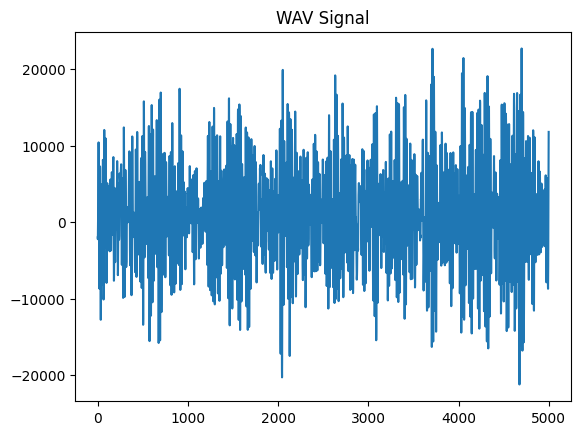

In [14]:
import scipy.io.wavfile as wav
import numpy as np
import matplotlib.pyplot as plt

# 1. WAV 파일 경로
path = "C:/Users/enjoy/Downloads/archive (2)/raw/converted_wav/B007_1_123.wav"  # 업로드된 파일 중 하나

# 2. 읽기
sr, data = wav.read(path)
print("샘플 수:", len(data))
print("샘플링 주파수:", sr)
print("최댓값:", np.max(data), "최솟값:", np.min(data))
print("평균:", np.mean(data), "표준편차:", np.std(data))

# 3. 시각화
plt.plot(data[:5000])  # 앞부분 일부만 시각화
plt.title("WAV Signal")
plt.show()


샘플 수: 483903
샘플링 주파수: 12000
최댓값: 30079 최솟값: -32767
평균: 1190.1585441710426 표준편차: 6171.683377796571


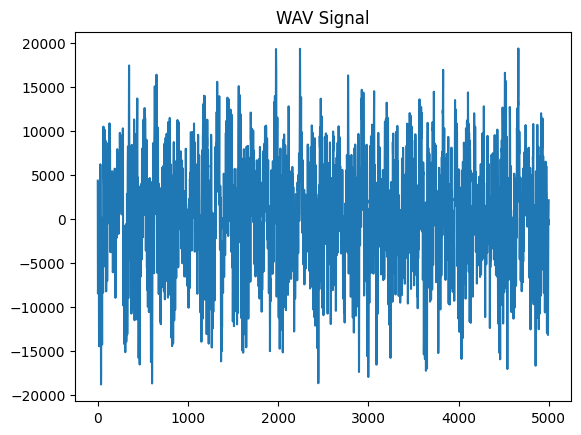

In [15]:
import scipy.io.wavfile as wav
import numpy as np
import matplotlib.pyplot as plt

# 1. WAV 파일 경로
path = "C:/Users/enjoy/Downloads/archive (2)/raw/converted_wav/Time_Normal_1_098.wav"  # 업로드된 파일 중 하나

# 2. 읽기
sr, data = wav.read(path)
print("샘플 수:", len(data))
print("샘플링 주파수:", sr)
print("최댓값:", np.max(data), "최솟값:", np.min(data))
print("평균:", np.mean(data), "표준편차:", np.std(data))

# 3. 시각화
plt.plot(data[:5000])  # 앞부분 일부만 시각화
plt.title("WAV Signal")
plt.show()

In [20]:
print(pd.Series(y_test).value_counts())


fault
3    143
0    142
1    142
2     47
Name: count, dtype: int64


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report
from xgboost import XGBClassifier

# 데이터 불러오기
df = pd.read_csv("your_stat_features.csv")  # 9개 통계 + fault 컬럼
X = df.drop(columns=["fault"])
y = df["fault"]

# 라벨 인코딩
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# 훈련/테스트 분할
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, stratify=y_encoded, test_size=0.2, random_state=42)

# XGBoost 분류기 + 하이퍼파라미터 튜닝
param_grid = {
    'learning_rate': [0.1],
    'max_depth': [3, 5],
    'n_estimators': [100, 300],
    'gamma': [0, 0.1]
}
clf = GridSearchCV(XGBClassifier(use_label_encoder=False, eval_metric='mlogloss'), param_grid, scoring='f1_macro', cv=3)
clf.fit(X_train, y_train)

# 평가
y_pred = clf.predict(X_test)
print("Best Params:", clf.best_params_)
print(classification_report(y_test, y_pred, target_names=le.classes_))


In [22]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, f1_score
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
from imblearn.over_sampling import RandomOverSampler
import joblib

# 1. 데이터 불러오기
df = pd.read_csv("C:/Users/enjoy/Downloads/archive (2)/raw/static/features_from_mat.csv")

# 2. 라벨 인코딩
le = LabelEncoder()
df['fault'] = le.fit_transform(df['fault'])

X = df.drop(columns=['fault'])
y = df['fault']

# 3. 학습/테스트 분할
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# 4. 오버샘플링 적용
ros = RandomOverSampler(random_state=42)
X_resampled, y_resampled = ros.fit_resample(X_train, y_train)

print("오버샘플링 후 클래스 분포:\n", pd.Series(y_resampled).value_counts())

# 5. XGBoost + GridSearchCV 설정
param_grid = {
    'learning_rate': [0.01, 0.1],
    'max_depth': [3, 5],
    'n_estimators': [100, 300],
    'gamma': [0, 0.1]
}

xgb = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)

grid = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring='f1_macro',
    cv=3,
    n_jobs=-1,
    verbose=2
)

# 6. 모델 학습 (오버샘플링된 데이터로)
grid.fit(X_resampled, y_resampled)

best_model = grid.best_estimator_

# 7. 테스트셋 예측 및 성능 평가
y_pred = best_model.predict(X_test)

print("\n Best Parameters:", grid.best_params_)
print(" CV Best Macro F1:", round(grid.best_score_, 4))
print("\n [Test Set Report]")
print(classification_report(y_test, y_pred, target_names=le.classes_))
print(" Test Set Macro F1:", round(f1_score(y_test, y_pred, average='macro'), 4))

# 8. 모델 + 인코더 저장
joblib.dump({'model': best_model, 'encoder': le}, "Xgboost_4class.pkl")
print(" 모델 저장 완료: Xgboost_4class.pkl")


c:\AIDC\Python39\lib\site-packages\sklearn\base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
c:\AIDC\Python39\lib\site-packages\sklearn\base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warnings.warn(


오버샘플링 후 클래스 분포:
 fault
3    569
0    569
1    569
2    569
Name: count, dtype: int64
Fitting 3 folds for each of 16 candidates, totalling 48 fits


c:\AIDC\Python39\lib\site-packages\sklearn\model_selection\_validation.py:528: FitFailedWarning: 
2 fits failed out of a total of 48.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
2 fits failed with the following error:
Traceback (most recent call last):
  File "c:\AIDC\Python39\lib\site-packages\sklearn\model_selection\_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\AIDC\Python39\lib\site-packages\xgboost\core.py", line 726, in inner_f
    return func(**kwargs)
  File "c:\AIDC\Python39\lib\site-packages\xgboost\sklearn.py", line 1580, in fit
    train_dmatrix, evals = _wrap_evaluation_matrices(
  File "c:\AIDC\Python39\lib\site-packages\xgboost\sklearn.py", line 603, in _wrap_e


 Best Parameters: {'gamma': 0.1, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 300}
 CV Best Macro F1: 0.8951

 [Test Set Report]
              precision    recall  f1-score   support

        Ball       0.79      0.80      0.80       142
          IR       0.93      1.00      0.97       142
      Normal       1.00      0.96      0.98        47
          OR       0.86      0.80      0.83       143

    accuracy                           0.88       474
   macro avg       0.90      0.89      0.89       474
weighted avg       0.87      0.88      0.87       474

 Test Set Macro F1: 0.8919
 모델 저장 완료: Xgboost_4class.pkl


In [27]:
print(classification_report(y_test, y_pred, target_names=le.classes_))



              precision    recall  f1-score   support

        Ball       0.79      0.80      0.80       142
          IR       0.93      1.00      0.97       142
      Normal       1.00      0.96      0.98        47
          OR       0.86      0.80      0.83       143

    accuracy                           0.88       474
   macro avg       0.90      0.89      0.89       474
weighted avg       0.87      0.88      0.87       474



In [29]:
from scipy.io import wavfile
import numpy as np

def extract_features_from_wav(wav_path):
    sr, data = wavfile.read(wav_path)
    data = data.astype(np.float32)
    data = (data - np.mean(data)) / (np.max(np.abs(data)) + 1e-6)

    features = {
        'max': np.max(data),
        'min': np.min(data),
        'mean': np.mean(data),
        'sd': np.std(data),
        'rms': np.sqrt(np.mean(np.square(data))),
        'skewness': pd.Series(data).skew(),
        'kurtosis': pd.Series(data).kurt(),
        'crest': np.max(np.abs(data)) / (np.sqrt(np.mean(np.square(data))) + 1e-6),
        'form': np.sqrt(np.mean(np.square(data))) / (np.mean(np.abs(data)) + 1e-6)
    }
    return pd.DataFrame([features])


In [32]:
import joblib

# 모델 + 인코더 로드
bundle = joblib.load("Xgboost_4class.pkl")
model = bundle['model']
encoder = bundle['encoder']

# 예측
features_df = extract_features_from_wav("C:/Users/enjoy/Downloads/archive (2)/raw/converted_wav/Time_Normal_1_098.wav")
pred = model.predict(features_df)
pred_label = encoder.inverse_transform(pred)[0]
print("예측 결과:", pred_label)


예측 결과: IR


In [33]:
import numpy as np
import pandas as pd
from scipy.io import wavfile
from scipy.fft import rfft, rfftfreq
import joblib

# 1. 특성 추출 함수
def extract_features_from_wav(wav_path):
    sr, data = wavfile.read(wav_path)
    data = data.astype(np.float32)
    data = (data - np.mean(data)) / (np.max(np.abs(data)) + 1e-6)

    fft_vals = np.abs(rfft(data))
    fft_freqs = rfftfreq(len(data), 1 / sr)
    fft_peak_idx = np.argmax(fft_vals)
    fft_peak_freq = fft_freqs[fft_peak_idx]
    fft_peak_mag = fft_vals[fft_peak_idx]

    features = {
        'max': np.max(data),
        'min': np.min(data),
        'mean': np.mean(data),
        'std': np.std(data),
        'rms': np.sqrt(np.mean(np.square(data))),
        'skewness': pd.Series(data).skew(),
        'kurtosis': pd.Series(data).kurt(),
        'crest_factor': np.max(np.abs(data)) / (np.sqrt(np.mean(np.square(data))) + 1e-6),
        'form_factor': np.sqrt(np.mean(np.square(data))) / (np.mean(np.abs(data)) + 1e-6),
        'abs_mean': np.mean(np.abs(data)),
        'iqr': np.percentile(data, 75) - np.percentile(data, 25),
        'zcr': ((data[:-1] * data[1:]) < 0).sum(),
        'fft_peak_freq': fft_peak_freq,
        'fft_peak_mag': fft_peak_mag
    }

    return pd.DataFrame([features])


# 2. 모델 로드
bundle = joblib.load("Xgboost_4class.pkl")
model = bundle['model']
encoder = bundle['encoder']

# 3. 예측 대상 wav 파일 경로
wav_path = "C:/Users/enjoy/Downloads/archive (2)/raw/converted_wav/Time_Normal_1_098.wav"

# 4. 특성 추출 + 예측
features_df = extract_features_from_wav(wav_path)
pred = model.predict(features_df)
pred_label = encoder.inverse_transform(pred)[0]

print("예측 결과:", pred_label)


ValueError: feature_names mismatch: ['max', 'min', 'mean', 'sd', 'rms', 'skewness', 'kurtosis', 'crest', 'form'] ['max', 'min', 'mean', 'std', 'rms', 'skewness', 'kurtosis', 'crest_factor', 'form_factor', 'abs_mean', 'iqr', 'zcr', 'fft_peak_freq', 'fft_peak_mag']
expected form, crest, sd in input data
training data did not have the following fields: fft_peak_freq, iqr, fft_peak_mag, abs_mean, crest_factor, form_factor, zcr, std

In [ ]:
import os
import pandas as pd
from tqdm import tqdm

# 기존 extract 함수 필요
from your_module import extract_features_from_wav  # 또는 위에 정의된 함수 복붙

def simplify_fault_from_filename(filename):
    if filename.startswith('B'):
        return 'Ball'
    elif filename.startswith('IR'):
        return 'IR'
    elif filename.startswith('OR'):
        return 'OR'
    else:
        return 'Normal'

# 1. 경로 설정
wav_dir = "C:/Users/enjoy/Downloads/archive (2)/raw/converted_wav"
out_csv_path = "C:/Users/enjoy/Downloads/archive (2)/raw/converted_wav/features_from_wav2.csv"

features_list = []

# 2. 각 wav 파일에 대해 feature 추출 + 라벨 추가
for fname in tqdm(os.listdir(wav_dir)):
    if not fname.endswith(".wav"):
        continue
    fpath = os.path.join(wav_dir, fname)
    
    try:
        features = extract_features_from_wav(fpath)
        features['label'] = simplify_fault_from_filename(fname)
        features['filename'] = fname
        features_list.append(features)
    except Exception as e:
        print(f"❌ {fname} 처리 실패: {e}")

# 3. CSV 저장
df_features = pd.concat(features_list, ignore_index=True)
df_features.to_csv(out_csv_path, index=False)
print(f" 저장 완료: {out_csv_path}")